<a href="https://colab.research.google.com/github/Shamiul-693/CICadversarial/blob/main/version_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# COMPLETE FEDERATED LEARNING FOR IoT SECURITY
# Dataset  : Edge-IIoTset (DNN Version)
# Model    : GRU + Federated Learning (FedAvg) + FGSM/PGD
# Platform : Google Colab
# ============================================================


# ╔═══════════════════════════════════════════════╗
# ║              CELL 1: INSTALL DEPENDENCIES               ║
# ╖═══════════════════════════════════════════════╝
!pip install -q protobuf==3.20.3
!pip uninstall -y flwr grpcio grpcio-tools
!pip install -q kaggle
!pip install -q flwr
!pip install -q flwr[simulation]
!pip install -q imbalanced-learn
!pip install -q torch torchvision
print("✅ All packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-health-checking 1.80.0 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 3.20.3 which is incompatible.
flwr 1.29.0 requires protobuf<7.0.0,>=5.28.0, but you have protobuf 3.20.3 which is incompatible.
googleapis-common-protos 1.73.1 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-bigquery-connection 1.21.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-language 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
proto-plus 1.27.2 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-logging 3.15.0 requires protobuf<8.0.0,>=4.25.8, but yo

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║              CELL 2: IMPORT ALL LIBRARIES               ║
# ╚══════════════════════════════════════════════════════════╝
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter, OrderedDict
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import flwr as fl
from flwr.common import Metrics

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries imported!")
print(f"🖥️  Device      : {device}")
print(f"🌸  Flower Ver  : {fl.__version__}")
print(f"🔥  PyTorch Ver : {torch.__version__}")



✅ Libraries imported!
🖥️  Device      : cuda
🌸  Flower Ver  : 1.29.0
🔥  PyTorch Ver : 2.10.0+cu128


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║          CELL 3: KAGGLE SETUP & DOWNLOAD                ║
# ╚══════════════════════════════════════════════════════════╝
from google.colab import files

print("📁 Upload your kaggle.json file...")
files.upload()

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API configured!")

print("\n📥 Downloading Edge-IIoTset dataset...")
!kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
print("📦 Extracting dataset...")
!unzip -q edgeiiotset-cyber-security-dataset-of-iot-iiot.zip -d /content/Edge-IIoTset
print("✅ Dataset ready!")



📁 Upload your kaggle.json file...


Saving kaggle.json to kaggle.json
✅ Kaggle API configured!

📥 Downloading Edge-IIoTset dataset...
Dataset URL: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
License(s): CC-BY-NC-SA-4.0
100% 1.63G/1.63G [00:20<00:00, 86.2MB/s]

📦 Extracting dataset...
✅ Dataset ready!


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║        CELL 4: GLOBAL CONFIGURATION                     ║
# ╚══════════════════════════════════════════════════════════╝
# ── Paths ────────────────────────────────────────────────────
DNN_FILE   = ("/content/Edge-IIoTset/Edge-IIoTset dataset/"
              "Selected dataset for ML and DL/"
              "DNN-EdgeIIoT-dataset.csv")
SAVE_DIR   = "/content/fl_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Feature Engineering ──────────────────────────────────────
TOP_K      = 40
CORR_THRESHOLD = 0.95
NORMAL_CAP = 200000
SMOTE_MIN  = 50000

# ── Federated Learning ───────────────────────────────────────
NUM_CLIENTS   = 5
NUM_ROUNDS    = 10
LOCAL_EPOCHS  = 3

# ── GRU Model ────────────────────────────────────────────────
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
DROPOUT       = 0.3

# ── Training ─────────────────────────────────────────────────
BATCH_SIZE    = 256
LEARNING_RATE = 0.001
PRE_EPOCHS    = 5
ADV_EPOCHS    = 10

# ── Adversarial ──────────────────────────────────────────────
EPSILON       = 0.1
ALPHA         = 0.01
PGD_STEPS     = 10
ADV_RATIO     = 0.5

print("✅ Configuration set!")
print(f"   TOP_K        : {TOP_K}")
print(f"   NUM_CLIENTS  : {NUM_CLIENTS}")
print(f"   NUM_ROUNDS   : {NUM_ROUNDS}")
print(f"   HIDDEN_SIZE  : {HIDDEN_SIZE}")
print(f"   BATCH_SIZE   : {BATCH_SIZE}")
print(f"   ADV_EPOCHS   : {ADV_EPOCHS}")

✅ Configuration set!
   TOP_K        : 40
   NUM_CLIENTS  : 5
   NUM_ROUNDS   : 10
   HIDDEN_SIZE  : 128
   BATCH_SIZE   : 256
   ADV_EPOCHS   : 10



   STEP 1: LOADING EDGE-IIoTset DATASET
✅ Dataset loaded! Shape: (2219201, 63)

📊 Dataset Info:
   Rows     : 2,219,201
   Columns  : 63
   Classes  : 15
   Missing  : 0

📋 Attack Type Distribution:
Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64


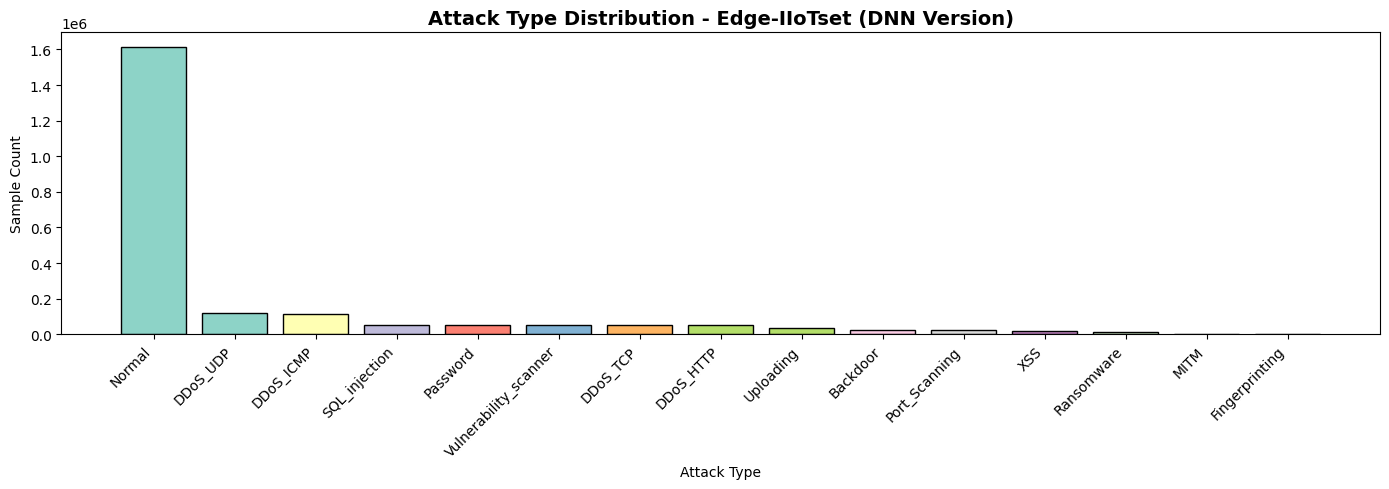

✅ Step 1 Complete!


In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║               STEP 1: LOAD DATASET                      ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*55)
print("   STEP 1: LOADING EDGE-IIoTset DATASET")
print("="*55)

df = pd.read_csv(DNN_FILE, low_memory=False)
print(f"✅ Dataset loaded! Shape: {df.shape}")

# Basic inspection
print(f"\n📊 Dataset Info:")
print(f"   Rows     : {df.shape[0]:,}")
print(f"   Columns  : {df.shape[1]}")
print(f"   Classes  : {df['Attack_type'].nunique()}")
print(f"   Missing  : {df.isnull().sum().sum()}")

print("\n📋 Attack Type Distribution:")
counts = df['Attack_type'].value_counts()
print(counts)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
colors  = plt.cm.Set3(np.linspace(0, 1, len(counts)))
ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
ax.set_title('Attack Type Distribution - Edge-IIoTset (DNN Version)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step1_distribution.png", dpi=150)
plt.show()
print("✅ Step 1 Complete!")


   STEP 2: PREPROCESSING & CLEANING
🗑️  Dropped 9 useless columns
   Remaining shape: (2219201, 54)

🔍 Missing values: 0
✅ Missing after fix: 0
✅ Infinite values fixed
🗑️  Removed 820 duplicates

🏷️  Label Encoding:
   Backdoor                            --> 0
   DDoS_HTTP                           --> 1
   DDoS_ICMP                           --> 2
   DDoS_TCP                            --> 3
   DDoS_UDP                            --> 4
   Fingerprinting                      --> 5
   MITM                                --> 6
   Normal                              --> 7
   Password                            --> 8
   Port_Scanning                       --> 9
   Ransomware                          --> 10
   SQL_injection                       --> 11
   Uploading                           --> 12
   Vulnerability_scanner               --> 13
   XSS                                 --> 14

📐 Features (X): (2218381, 53)
📐 Labels   (y): (2218381,)
✅ Scaling done | Mean≈0.0000 Std≈1.0000

📊 Tr

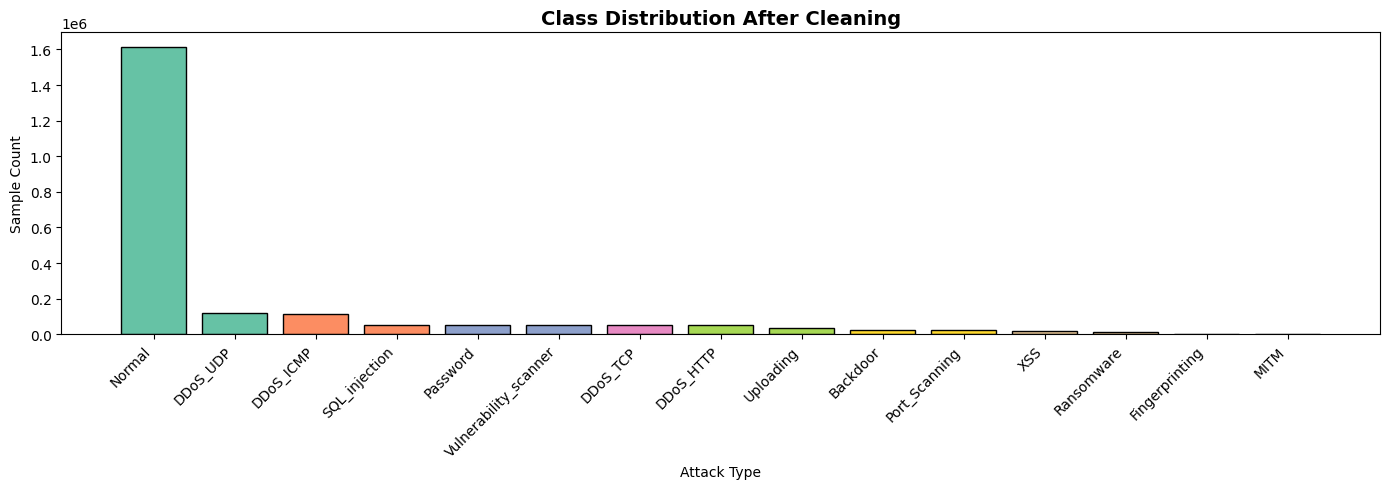


   Final Shape   : (2218381, 55)
   Total Features: 53
   Total Classes : 15
   Train Samples : 1,774,704
   Test  Samples : 443,677
✅ Step 2 Complete!


In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║            STEP 2: PREPROCESSING & CLEANING             ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*55)
print("   STEP 2: PREPROCESSING & CLEANING")
print("="*55)

# ── 2.1 Drop useless columns ─────────────────────────────────
single_val = [c for c in df.columns if df[c].nunique() == 1]
ip_cols    = [c for c in df.columns
              if any(x in c.lower()
                     for x in ['ip', 'mac', 'addr', 'timestamp'])]
to_drop    = list(set(single_val + ip_cols))
df         = df.drop(columns=to_drop, errors='ignore')
print(f"🗑️  Dropped {len(to_drop)} useless columns")
print(f"   Remaining shape: {df.shape}")

# ── 2.2 Handle missing values ────────────────────────────────
print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")

high_miss = [c for c in df.columns
             if df[c].isnull().mean() > 0.5]
df        = df.drop(columns=high_miss, errors='ignore')

num_cols  = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols  = [c for c in df.select_dtypes(
    include='object').columns if c != 'Attack_type']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"✅ Missing after fix: {df.isnull().sum().sum()}")

# ── 2.3 Handle infinite values ───────────────────────────────
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(f"✅ Infinite values fixed")

# ── 2.4 Remove duplicates ────────────────────────────────────
before = len(df)
df     = df.drop_duplicates()
print(f"🗑️  Removed {before - len(df):,} duplicates")

# ── 2.5 Encode target label ──────────────────────────────────
le                        = LabelEncoder()
df['Attack_type_encoded'] = le.fit_transform(df['Attack_type'])
print(f"\n🏷️  Label Encoding:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"   {cls:35s} --> {code}")

# ── 2.6 Encode categorical features ─────────────────────────
le_feat   = LabelEncoder()
obj_feats = [c for c in df.select_dtypes(
    include='object').columns if c != 'Attack_type']
for col in obj_feats:
    df[col] = le_feat.fit_transform(df[col].astype(str))

# ── 2.7 Feature / label split ────────────────────────────────
X = df.drop(columns=['Attack_type', 'Attack_type_encoded'],
            errors='ignore')
y = df['Attack_type_encoded']
print(f"\n📐 Features (X): {X.shape}")
print(f"📐 Labels   (y): {y.shape}")

# ── 2.8 Feature scaling ──────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(f"✅ Scaling done | Mean≈{X_scaled.mean().mean():.4f} Std≈{X_scaled.std().mean():.4f}")

# ── 2.9 Train/test split ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)
print(f"\n📊 Train/Test Split:")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")

# ── 2.10 Class distribution plot ─────────────────────────────
counts2 = df['Attack_type'].value_counts()
fig, ax  = plt.subplots(figsize=(14, 5))
colors2  = plt.cm.Set2(np.linspace(0, 1, len(counts2)))
ax.bar(counts2.index, counts2.values, color=colors2, edgecolor='black')
ax.set_title('Class Distribution After Cleaning',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step2_class_dist.png", dpi=150)
plt.show()

# ── Save ─────────────────────────────────────────────────────
X_train.to_csv(f"{SAVE_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{SAVE_DIR}/X_test.csv",   index=False)
y_train.to_csv(f"{SAVE_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{SAVE_DIR}/y_test.csv",   index=False)
with open(f"{SAVE_DIR}/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)
with open(f"{SAVE_DIR}/label_encoder.pkl", 'wb') as f:
    pickle.dump(le, f)

print("\n" + "="*55)
print(f"   Final Shape   : {df.shape}")
print(f"   Total Features: {X_scaled.shape[1]}")
print(f"   Total Classes : {y.nunique()}")
print(f"   Train Samples : {X_train.shape[0]:,}")
print(f"   Test  Samples : {X_test.shape[0]:,}")
print("✅ Step 2 Complete!")
print("="*55)



   STEP 3: FEATURE ENGINEERING & BALANCING

🔗 Removing highly correlated features...
   Dropped 6 correlated features
   Shape: (1774704, 47)

🎯 Selecting top 40 features (mutual_info)...
   Selected 40 features
   Top features: ['frame.time', 'arp.opcode', 'arp.hw.size', 'icmp.checksum', 'icmp.seq_le']...

🌲 Computing RF feature importance...


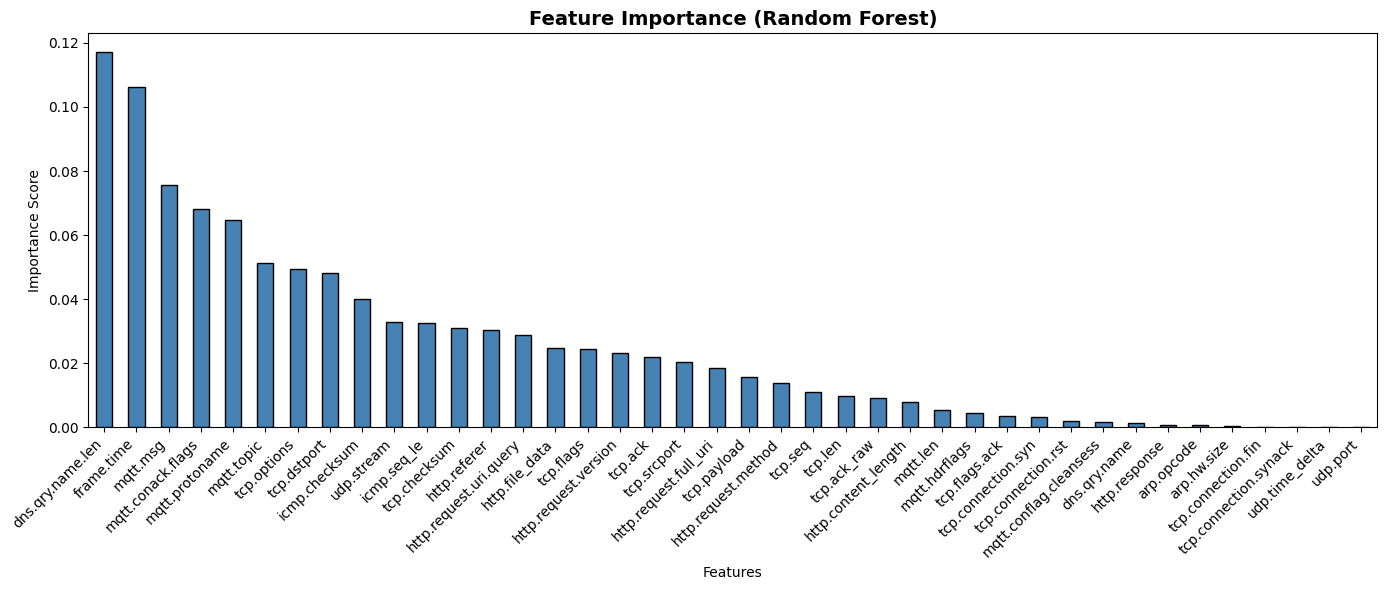

   Top 5 features:
dns.qry.name.len     0.117124
frame.time           0.106167
mqtt.msg             0.075771
mqtt.conack.flags    0.068232
mqtt.protoname       0.064615

⚖️  Balancing classes...
   After undersampling: 682,190 samples
   After SMOTE: 990,402 samples
   Imbalance ratio: 4.00x


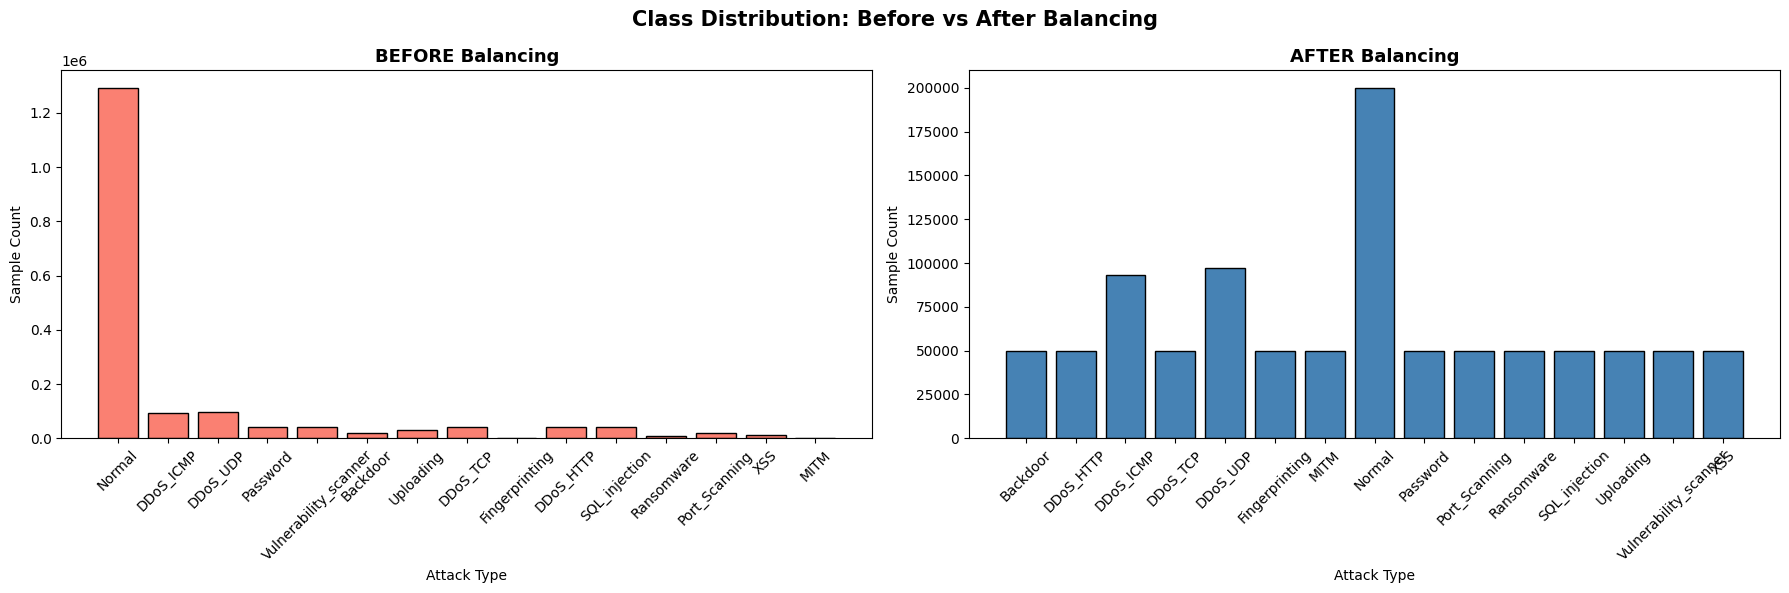


⚖️  Class weights computed:
   Backdoor                       --> 1.3205
   DDoS_HTTP                      --> 1.3205
   DDoS_ICMP                      --> 0.7088
   DDoS_TCP                       --> 1.3205
   DDoS_UDP                       --> 0.6789
   Fingerprinting                 --> 1.3205
   MITM                           --> 1.3205
   Normal                         --> 0.3301
   Password                       --> 1.3205
   Port_Scanning                  --> 1.3205
   Ransomware                     --> 1.3205
   SQL_injection                  --> 1.3205
   Uploading                      --> 1.3205
   Vulnerability_scanner          --> 1.3205
   XSS                            --> 1.3205

📐 GRU-ready shapes:
   X_train_gru   : (990402, 1, 40)
   X_test_gru    : (443677, 1, 40)

   Original Features : 47
   Selected Features : 40
   Train Samples     : 990,402
   GRU Input Shape   : (990402, 1, 40)
   Num Classes       : 15
✅ Step 3 Complete!


In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║         STEP 3: FEATURE ENGINEERING & BALANCING         ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*55)
print("   STEP 3: FEATURE ENGINEERING & BALANCING")
print("="*55)

# ── 3.1 Correlation filter ───────────────────────────────────
print("\n🔗 Removing highly correlated features...")
corr    = X_train.corr().abs()
upper   = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
hi_corr = [c for c in upper.columns
           if any(upper[c] > CORR_THRESHOLD)]
X_train = X_train.drop(columns=hi_corr, errors='ignore')
X_test  = X_test.drop(columns=hi_corr,  errors='ignore')
print(f"   Dropped {len(hi_corr)} correlated features")
print(f"   Shape: {X_train.shape}")

# ── 3.2 SelectKBest ──────────────────────────────────────────
print(f"\n🎯 Selecting top {TOP_K} features (mutual_info)...")
selector     = SelectKBest(mutual_info_classif, k=TOP_K)
X_train_sel  = selector.fit_transform(X_train, y_train)
X_test_sel   = selector.transform(X_test)
selected     = X_train.columns[selector.get_support()].tolist()
X_train_sel  = pd.DataFrame(X_train_sel, columns=selected)
X_test_sel   = pd.DataFrame(X_test_sel,  columns=selected)
print(f"   Selected {len(selected)} features")
print(f"   Top features: {selected[:5]}...")

# ── 3.3 Feature importance plot ──────────────────────────────
print("\n🌲 Computing RF feature importance...")
rf  = RandomForestClassifier(n_estimators=50,
                              random_state=42, n_jobs=-1)
n   = min(50000, len(X_train_sel))
idx = np.random.choice(len(X_train_sel), n, replace=False)
rf.fit(X_train_sel.iloc[idx], y_train.iloc[idx])

imp = pd.Series(rf.feature_importances_,
                index=selected).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 6))
imp.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Feature Importance (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step3_feature_importance.png", dpi=150)
plt.show()
print("   Top 5 features:")
print(imp.head(5).to_string())

# ── 3.4 Undersample majority class ───────────────────────────
print("\n⚖️  Balancing classes...")
before_counts  = Counter(y_train)
under_strategy = {cls: min(cnt, NORMAL_CAP)
                  for cls, cnt in before_counts.items()}
under          = RandomUnderSampler(
    sampling_strategy=under_strategy, random_state=42
)
X_under, y_under = under.fit_resample(X_train_sel, y_train)
print(f"   After undersampling: {len(X_under):,} samples")

# ── 3.5 SMOTE oversampling ───────────────────────────────────
after_under    = Counter(y_under)
smote_strategy = {cls: SMOTE_MIN
                  for cls, cnt in after_under.items()
                  if cnt < SMOTE_MIN}
if smote_strategy:
    smote        = SMOTE(sampling_strategy=smote_strategy,
                         random_state=42, k_neighbors=3)
    X_bal, y_bal = smote.fit_resample(X_under, y_under)
else:
    X_bal, y_bal = X_under, y_under

after_counts = Counter(y_bal)
ratio        = max(after_counts.values()) / min(after_counts.values())
print(f"   After SMOTE: {len(X_bal):,} samples")
print(f"   Imbalance ratio: {ratio:.2f}x")

# ── 3.6 Before / After plot ──────────────────────────────────
def named_counter(counter, le):
    return {le.classes_[k]: v for k, v in counter.items()}

b_named = named_counter(before_counts, le)
a_named = named_counter(after_counts,  le)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(b_named.keys(), b_named.values(),
            color='salmon', edgecolor='black')
axes[0].set_title('BEFORE Balancing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(a_named.keys(), a_named.values(),
            color='steelblue', edgecolor='black')
axes[1].set_title('AFTER Balancing', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Sample Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Class Distribution: Before vs After Balancing',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step3_balance.png", dpi=150)
plt.show()

# ── 3.7 Class weights ────────────────────────────────────────
classes        = np.unique(y_bal)
weights_arr    = compute_class_weight('balanced',
                                      classes=classes, y=y_bal)
class_weight_dict = dict(zip(classes, weights_arr))
print("\n⚖️  Class weights computed:")
for idx, w in class_weight_dict.items():
    print(f"   {le.classes_[idx]:30s} --> {w:.4f}")

# ── 3.8 Reshape for GRU (samples, timesteps=1, features) ─────
X_train_gru   = np.array(X_bal).reshape(
    len(X_bal), 1, X_bal.shape[1])
X_test_gru    = np.array(X_test_sel).reshape(
    len(X_test_sel), 1, X_test_sel.shape[1])
y_train_final = np.array(y_bal)
y_test_final  = np.array(y_test)

print(f"\n📐 GRU-ready shapes:")
print(f"   X_train_gru   : {X_train_gru.shape}")
print(f"   X_test_gru    : {X_test_gru.shape}")

# ── Save ─────────────────────────────────────────────────────
np.save(f"{SAVE_DIR}/X_train_gru.npy",   X_train_gru)
np.save(f"{SAVE_DIR}/X_test_gru.npy",    X_test_gru)
np.save(f"{SAVE_DIR}/y_train_final.npy", y_train_final)
np.save(f"{SAVE_DIR}/y_test_final.npy",  y_test_final)
with open(f"{SAVE_DIR}/class_weights.pkl", 'wb') as f:
    pickle.dump(class_weight_dict, f)
with open(f"{SAVE_DIR}/selected_features.pkl", 'wb') as f:
    pickle.dump(selected, f)

print("\n" + "="*55)
print(f"   Original Features : {X_train.shape[1]}")
print(f"   Selected Features : {len(selected)}")
print(f"   Train Samples     : {len(y_train_final):,}")
print(f"   GRU Input Shape   : {X_train_gru.shape}")
print(f"   Num Classes       : {len(np.unique(y_train_final))}")
print("✅ Step 3 Complete!")
print("="*55)



   STEP 4: FEDERATED LEARNING SIMULATION

 GRU Model:
   Input Size    : 40
   Hidden Size   : 128
   Num Layers    : 2
   Num Classes   : 15
   Parameters    : 166,543

── Partitioning data (5 clients, IID)...
   Client 1 | Samples: 198,080 | Classes: 15
   Client 2 | Samples: 198,080 | Classes: 15
   Client 3 | Samples: 198,080 | Classes: 15
   Client 4 | Samples: 198,080 | Classes: 15
   Client 5 | Samples: 198,082 | Classes: 15


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



 Starting Federated Learning Simulation...
   Clients  : 5
   Rounds   : 10
   Strategy : FedAvg



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-04-14 08:14:22,285	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 9266208359.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0, 'CPU': 2.0, 'object_store_memory': 3971232153.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=1696

(ClientAppActor pid=16966)    [Client 3] Loss: 0.0913 | Acc: 0.9911


...

(ClientAppActor pid=16965) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=16965) 
(ClientAppActor pid=16965)             This is a deprecated feature. It will be removed
(ClientAppActor pid=16965)             entirely in future versions of Flower.
(ClientAppActor pid=16965)         
ERROR :     Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/flwr/simulation/ray_transport/ray_client_proxy.py", line 90, in _submit_job
    out_mssg, updated_context = self.actor_pool.get_client_result(
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/flwr/simulation/ray_transport/ray_actor.py", line 400, in get_client_result
    return self._fetch_future_result(cid)
           ^^^^^^^^^^^^

(ClientAppActor pid=16965)    [Client 4] Loss: 0.0231 | Acc: 0.9941


(ClientAppActor pid=16965) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=16965) 
(ClientAppActor pid=16965)             This is a deprecated feature. It will be removed
(ClientAppActor pid=16965)             entirely in future versions of Flower.
(ClientAppActor pid=16965)         
ERROR :     Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/flwr/simulation/ray_transport/ray_client_proxy.py", line 90, in _submit_job
    out_mssg, updated_context = self.actor_pool.get_client_result(
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/flwr/simulation/ray_transport/ray_actor.py", line 400, in get_client_result
    return self._fetch_future_result(cid)
           ^^^^^^^^^^^^

(ClientAppActor pid=16965)    [Client 4] Loss: 0.0208 | Acc: 0.9946


(ClientAppActor pid=16965) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=16965) 
(ClientAppActor pid=16965)             This is a deprecated feature. It will be removed
(ClientAppActor pid=16965)             entirely in future versions of Flower.
(ClientAppActor pid=16965)         
ERROR :     Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/flwr/simulation/ray_transport/ray_client_proxy.py", line 90, in _submit_job
    out_mssg, updated_context = self.actor_pool.get_client_result(
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/flwr/simulation/ray_transport/ray_actor.py", line 400, in get_client_result
    return self._fetch_future_result(cid)
           ^^^^^^^^^^^^

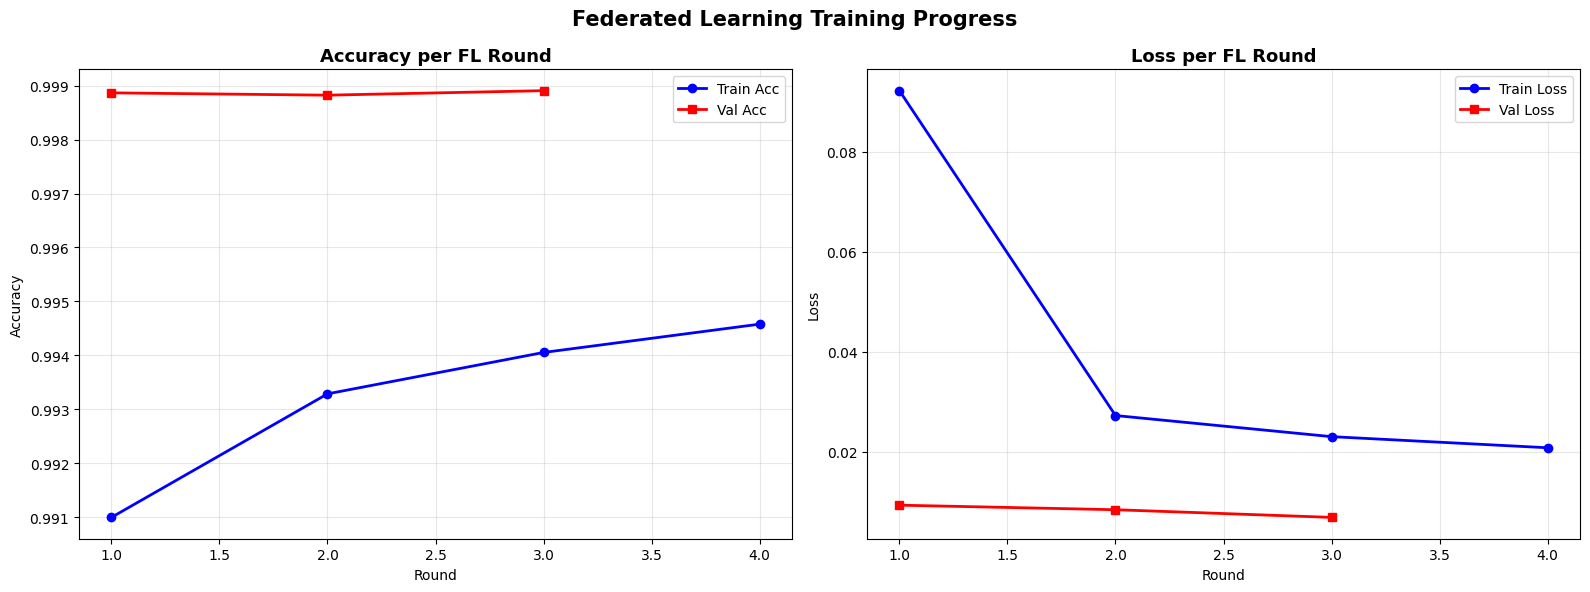

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



   FL Rounds    : 10
   Clients      : 5
   Parameters   : 166,543
✅ Step 4 Complete!


In [ ]:


# ╔═══════════════════════════════════════════════╗
# ║            STEP 4: FEDERATED LEARNING SETUP             ║
# ╖═══════════════════════════════════════════════╝
print("\n" + "="*55)
print("   STEP 4: FEDERATED LEARNING SIMULATION")
print("="*55)

INPUT_SIZE  = X_train_gru.shape[2]
NUM_CLASSES = len(np.unique(y_train_final))

# ── 4.1 GRU Model definition ──────────────────────────────
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size,
                 num_layers, num_classes, dropout=0.3):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )
        self.batch_norm = nn.BatchNorm1d(hidden_size)
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0  = torch.zeros(
            self.num_layers, x.size(0), self.hidden_size
        ).to(x.device)
        out, _ = self.gru(x, h0)
        out     = out[:, -1, :]
        out     = self.batch_norm(out)
        out     = self.dropout(out)
        return self.fc(out)

model_cfg = {
    'input_size' : INPUT_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers' : NUM_LAYERS,
    'num_classes': NUM_CLASSES,
    'dropout'    : DROPOUT
}

test_model = GRUModel(**model_cfg)
params     = sum(p.numel() for p in test_model.parameters())
print(f"\n GRU Model:")
print(f"   Input Size    : {INPUT_SIZE}")
print(f"   Hidden Size   : {HIDDEN_SIZE}")
print(f"   Num Layers    : {NUM_LAYERS}")
print(f"   Num Classes   : {NUM_CLASSES}")
print(f"   Parameters    : {params:,}")

# ── 4.2 DataLoader helper ──────────────────────────────
def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(
        torch.FloatTensor(X),
        torch.LongTensor(y)
    )
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=shuffle, num_workers=0)

# ── 4.3 IID Data partitioning ──────────────────────────
def partition_iid(X, y, num_clients):
    print(f"\n── Partitioning data ({num_clients} clients, IID)...")
    idx  = np.random.permutation(len(X))
    size = len(X) // num_clients
    parts = []
    for i in range(num_clients):
        s  = i * size
        e  = s + size if i < num_clients - 1 else len(X)
        Xi = X[idx[s:e]]
        yi = y[idx[s:e]]
        parts.append((Xi, yi))
        print(f"   Client {i+1} | Samples: {len(Xi):,} | "
              f"Classes: {len(np.unique(yi))}")
    return parts

parts          = partition_iid(X_train_gru, y_train_final,
                                NUM_CLIENTS)
test_loader    = make_loader(X_test_gru, y_test_final,
                              BATCH_SIZE, shuffle=False)
client_loaders = [make_loader(X, y, BATCH_SIZE)
                  for X, y in parts]

# ── 4.4 Flower client ──────────────────────────────
class IoTFlowerClient(fl.client.NumPyClient):
    def __init__(self, cid, train_loader,
                 test_loader, model_cfg, cw_dict):
        self.cid          = cid
        self.train_loader = train_loader
        self.test_loader  = test_loader
        # Force client to use CPU as client_resources['num_gpus'] is 0.0
        self.device       = torch.device('cpu')

        self.model = GRUModel(**model_cfg).to(self.device)

        w = torch.FloatTensor(
            [cw_dict.get(i, 1.0)
             for i in range(model_cfg['num_classes'])]
        ).to(self.device)
        self.criterion = nn.CrossEntropyLoss(weight=w)
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=LEARNING_RATE, weight_decay=1e-4
        )
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=2, gamma=0.5
        )

    def get_parameters(self, config):
        return [v.cpu().numpy()
                for _, v in self.model.state_dict().items()]

    def set_parameters(self, params):
        sd = OrderedDict(
            {k: torch.tensor(v)
             for k, v in zip(
                 self.model.state_dict().keys(), params)}
        )
        self.model.load_state_dict(sd, strict=True)

    def fit(self, params, config):
        self.set_parameters(params)
        self.model.train()
        total_loss, ep_correct = 0, 0

        for _ in range(LOCAL_EPOCHS):
            ep_correct = 0
            for Xb, yb in self.train_loader:
                Xb, yb = Xb.to(self.device), yb.to(self.device)
                self.optimizer.zero_grad()
                out  = self.model(Xb)
                loss = self.criterion(out, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), 1.0
                )
                self.optimizer.step()
                total_loss += loss.item()
                ep_correct += (out.argmax(1) == yb).sum().item()

        self.scheduler.step()
        acc = ep_correct / len(self.train_loader.dataset)
        avg = total_loss / (LOCAL_EPOCHS * len(self.train_loader))
        print(f"   [Client {self.cid}] "
              f"Loss: {avg:.4f} | Acc: {acc:.4f}")
        return (self.get_parameters({}),
                len(self.train_loader.dataset),
                {"loss": avg, "accuracy": acc})

    def evaluate(self, params, config):
        self.set_parameters(params)
        self.model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for Xb, yb in self.test_loader:
                Xb, yb = Xb.to(self.device), yb.to(self.device)
                out     = self.model(Xb)
                total_loss += self.criterion(out, yb).item()
                correct    += (out.argmax(1) == yb).sum().item()
                total      += yb.size(0)

        acc = correct / total
        avg = total_loss / len(self.test_loader)
        return avg, total, {"accuracy": acc, "loss": avg}

# ── 4.5 FedAvg strategy ──────────────────────────────
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    total = sum(n for n, _ in metrics)
    acc   = sum(n * m["accuracy"] for n, m in metrics) / total
    loss  = sum(n * m["loss"]     for n, m in metrics) / total
    return {"accuracy": acc, "loss": loss}

strategy = fl.server.strategy.FedAvg(
    fraction_fit                    = 1.0,
    fraction_evaluate               = 1.0,
    min_fit_clients                 = NUM_CLIENTS,
    min_evaluate_clients            = NUM_CLIENTS,
    min_available_clients           = NUM_CLIENTS,
    fit_metrics_aggregation_fn      = weighted_average,
    evaluate_metrics_aggregation_fn = weighted_average,
)

def client_fn(cid: str):
    return IoTFlowerClient(
        int(cid),
        client_loaders[int(cid)],
        test_loader,
        model_cfg,
        class_weight_dict
    ).to_client()

# ── 4.6 Run FL simulation ──────────────────────────────
print(f"\n Starting Federated Learning Simulation...")
print(f"   Clients  : {NUM_CLIENTS}")
print(f"   Rounds   : {NUM_ROUNDS}")
print(f"   Strategy : FedAvg\n")

history = fl.simulation.start_simulation(
    client_fn        = client_fn,
    num_clients      = NUM_CLIENTS,
    config           = fl.server.ServerConfig(
        num_rounds=NUM_ROUNDS
    ),
    strategy         = strategy,
    client_resources = {"num_cpus": 1, "num_gpus": 0.0}
)

# ── 4.7 Plot FL history ──────────────────────────────
rounds     = list(range(1, NUM_ROUNDS + 1))
fit_m      = history.metrics_distributed_fit
eval_m     = history.metrics_distributed
train_acc  = [m[1] for m in fit_m.get('accuracy', [])]
train_loss = [m[1] for m in fit_m.get('loss', [])]
val_acc    = [m[1] for m in eval_m.get('accuracy', [])]
val_loss   = [m[1] for m in eval_m.get('loss', [])]

fig, axes  = plt.subplots(1, 2, figsize=(16, 6))
if train_acc:
    axes[0].plot(rounds[:len(train_acc)], train_acc,
                 'b-o', label='Train Acc', linewidth=2)
if val_acc:
    axes[0].plot(rounds[:len(val_acc)], val_acc,
                 'r-s', label='Val Acc', linewidth=2)
axes[0].set_title('Accuracy per FL Round',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if train_loss:
    axes[1].plot(rounds[:len(train_loss)], train_loss,
                 'b-o', label='Train Loss', linewidth=2)
if val_loss:
    axes[1].plot(rounds[:len(val_loss)], val_loss,
                 'r-s', label='Val Loss', linewidth=2)
axes[1].set_title('Loss per FL Round',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Federated Learning Training Progress',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step4_fl_history.png", dpi=150)
plt.show()

# Save FL model
fl_model = GRUModel(**model_cfg).to(device)
torch.save({
    'model_state_dict': fl_model.state_dict(),
    'model_config'    : model_cfg,
    'num_rounds'      : NUM_ROUNDS,
    'num_clients'     : NUM_CLIENTS,
}, f"{SAVE_DIR}/federated_gru_model.pth")

print("\n" + "="*55)
print(f"   FL Rounds    : {NUM_ROUNDS}")
print(f"   Clients      : {NUM_CLIENTS}")
print(f"   Parameters   : {params:,}")
print("✅ Step 4 Complete!")
print("="*55)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



   STEP 5: ADVERSARIAL TRAINING (FGSM & PGD)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   Train batches : 3869
   Test  batches : 1734

ʙ Pre-Training Baseline (5 epochs)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   [FGSM] Acc: 0.8687 | F1: 0.9011 | Drop: 13.07%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   [PGD] Acc: 0.8935 | F1: 0.9203 | Drop: 10.59%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


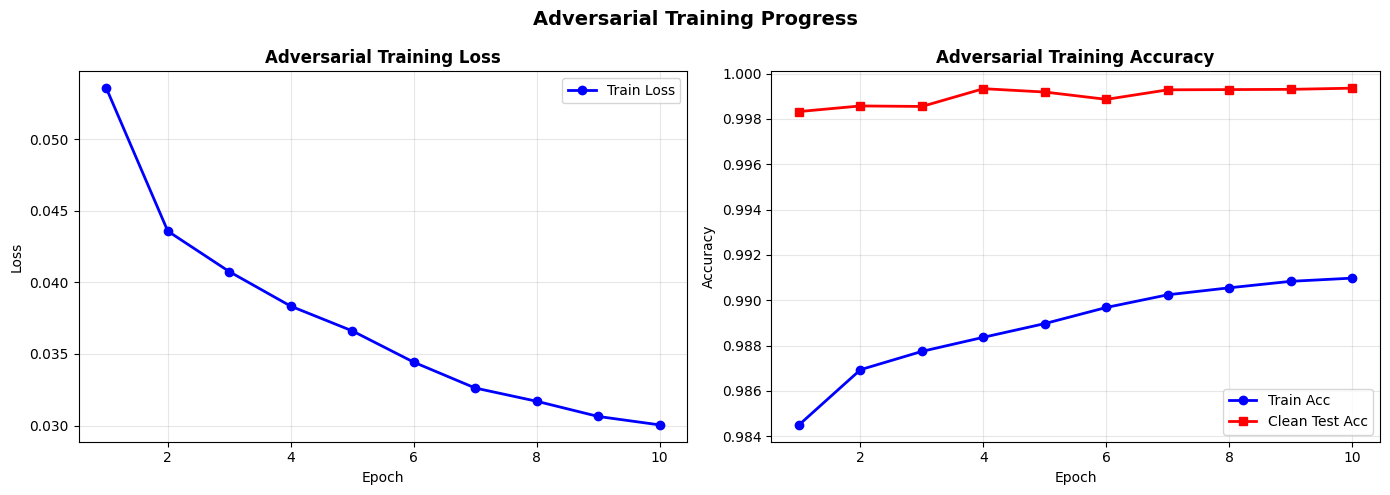

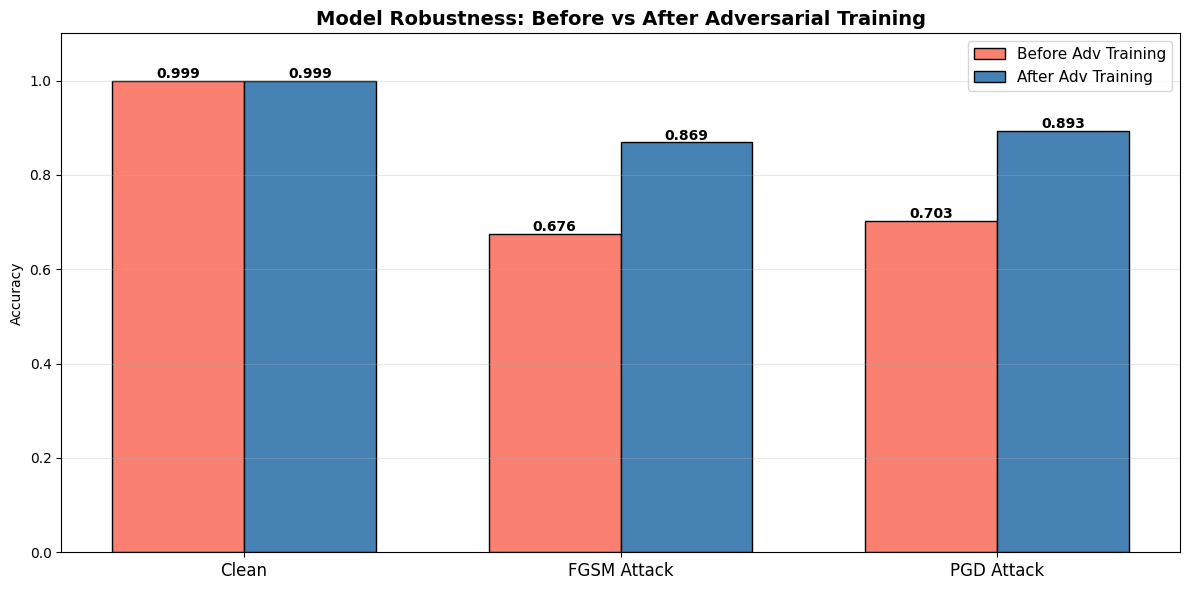

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



┐ Classification Report (Clean Test Data):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


                       precision    recall  f1-score   support

             Backdoor       1.00      0.99      0.99      4972
            DDoS_HTTP       1.00      1.00      1.00      9982
            DDoS_ICMP       1.00      1.00      1.00     23287
             DDoS_TCP       1.00      1.00      1.00     10012
             DDoS_UDP       1.00      1.00      1.00     24314
       Fingerprinting       0.82      1.00      0.90       200
                 MITM       1.00      1.00      1.00        79
               Normal       1.00      1.00      1.00    323129
             Password       1.00      1.00      1.00     10031
        Port_Scanning       0.98      0.99      0.99      4513
           Ransomware       0.95      0.96      0.96      2185
        SQL_injection       1.00      1.00      1.00     10241
            Uploading       1.00      1.00      1.00      7527
Vulnerability_scanner       1.00      1.00      1.00     10022
                  XSS       0.99      1.00      1.00  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

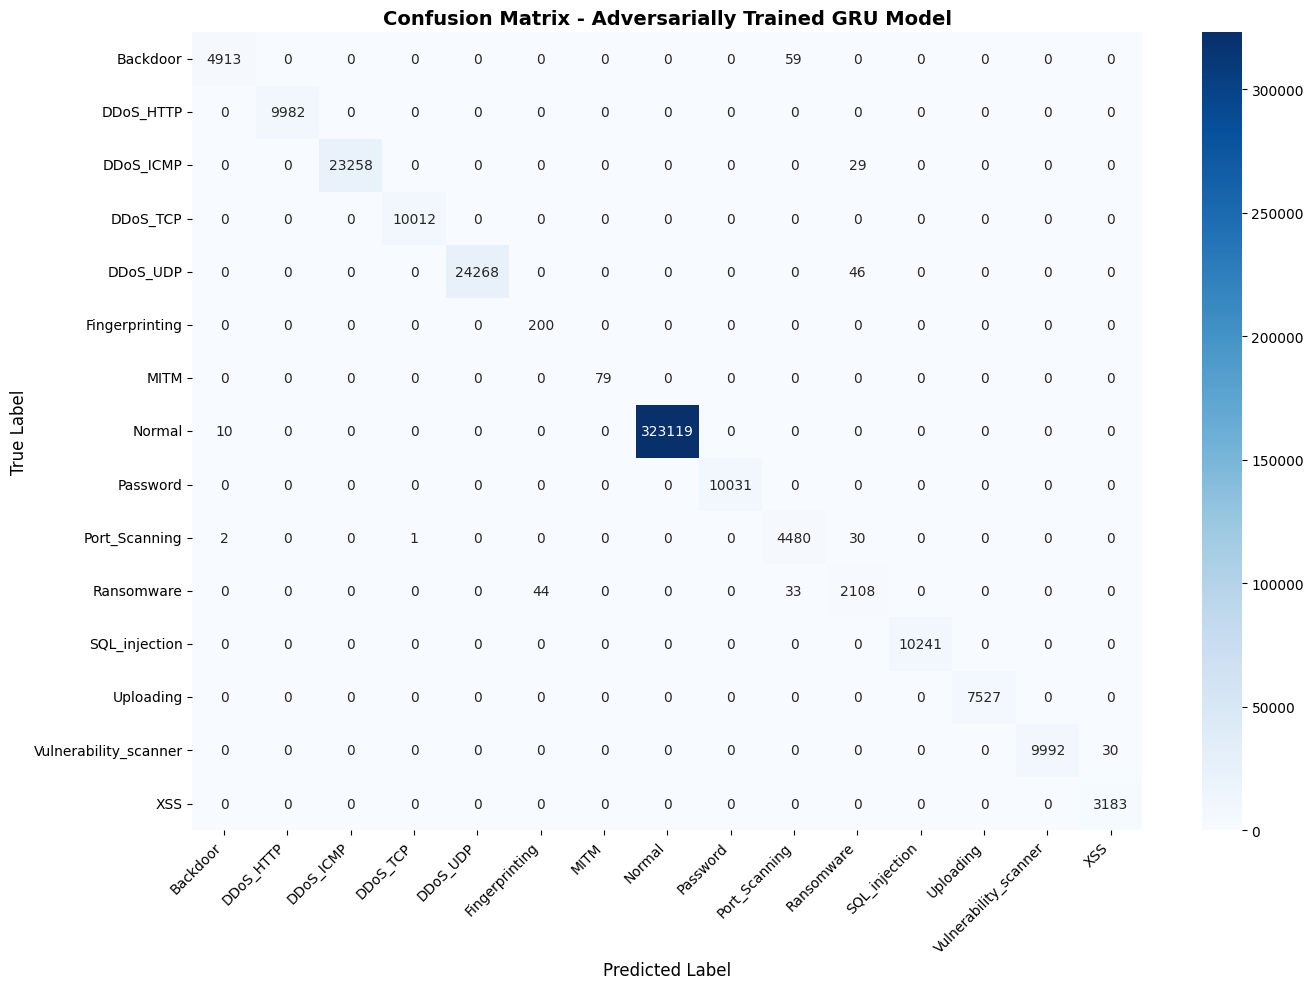


         COMPLETE RESEARCH RESULTS SUMMARY

  ʘ Dataset        : Edge-IIoTset (DNN Version)
  ʘ Model          : GRU + FedAvg + Adversarial Training
  ʘ FL Clients     : 5
  ʘ FL Rounds      : 10
  ʘ Features Used  : 40
  ʘ Classes        : 15
  ʘ Parameters     : 166,543

  Metric                          Before     After
  ------------------------------------------------
  Clean Accuracy                  0.9994    0.9994
  FGSM Accuracy                   0.6755    0.8687
  PGD  Accuracy                   0.7027    0.8935
  Clean F1-Score                  0.9994    0.9994
  FGSM F1-Score                   0.7283    0.9011
  PGD  F1-Score                   0.7543    0.9203

  ɡ All outputs saved to: /content/fl_outputs
     ├── step1_distribution.png
     ├── step2_class_dist.png
     ├── step3_feature_importance.png
     ├── step3_balance.png
     ├── step4_fl_history.png
     ├── step5_adv_history.png
     ├── step5_robustness.png
     ├── step5_confusion_matrix.png
     ├── federat

In [ ]:






# ╔═══════════════════════════════════════════════╗
# ║         STEP 5: ADVERSARIAL TRAINING (FGSM & PGD)      ║
# ╖═══════════════════════════════════════════════╝
print("\n" + "="*55)
print("   STEP 5: ADVERSARIAL TRAINING (FGSM & PGD)")
print("="*55)

# ── 5.1 Initialize fresh model & loaders ───────────────────
model     = GRUModel(**model_cfg).to(device)
w_tensor  = torch.FloatTensor(
    [class_weight_dict.get(i, 1.0) for i in range(NUM_CLASSES)]
).to(device)
criterion = nn.CrossEntropyLoss(weight=w_tensor)
optimizer = optim.Adam(model.parameters(),
                       lr=LEARNING_RATE, weight_decay=1e-4)

train_loader = make_loader(X_train_gru, y_train_final, BATCH_SIZE)
test_loader  = make_loader(X_test_gru,  y_test_final,
                           BATCH_SIZE, shuffle=False)

print(f"   Train batches : {len(train_loader)}")
print(f"   Test  batches : {len(test_loader)}")

# ── 5.2 FGSM attack ──────────────────────────────
def fgsm_attack(model, X, y, epsilon=0.1):
    """Fast Gradient Sign Method"""
    original_mode = model.training # Store original mode
    model.train() # Temporarily set to train mode for gradient computation
    X_adv = X.clone().detach().requires_grad_(True)
    out   = model(X_adv)
    loss  = nn.CrossEntropyLoss()(out, y)
    model.zero_grad()
    loss.backward()
    # Restore original mode
    if not original_mode:
        model.eval()
    return (X_adv + epsilon * X_adv.grad.data.sign()).detach()

# ── 5.3 PGD attack ───────────────────────────────
def pgd_attack(model, X, y, epsilon=0.1,
               alpha=0.01, num_steps=10):
    """Projected Gradient Descent"""
    original_mode = model.training # Store original mode
    model.train() # Temporarily set to train mode for gradient computation
    X_adv = X.clone().detach()
    X_adv = X_adv + torch.empty_like(X_adv).uniform_(
        -epsilon, epsilon
    )
    for _ in range(num_steps):
        X_adv.requires_grad_(True)
        out  = model(X_adv)
        loss = nn.CrossEntropyLoss()(out, y)
        model.zero_grad()
        loss.backward()
        X_adv = X_adv.detach() + alpha * X_adv.grad.data.sign()
        delta = torch.clamp(X_adv - X, -epsilon, epsilon)
        X_adv = (X + delta).detach()
    # Restore original mode
    if not original_mode:
        model.eval()
    return X_adv

# ── 5.4 Evaluation helpers ───────────────────────────
def evaluate_clean(model, loader):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    all_preds, all_labels    = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb  = Xb.to(device), yb.to(device)
            out      = model(Xb)
            loss_sum += criterion(out, yb).item()
            preds    = out.argmax(dim=1)
            correct  += (preds == yb).sum().item()
            total    += yb.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    acc = correct / total
    f1  = f1_score(all_labels, all_preds, average='weighted')
    avg = loss_sum / len(loader)
    return acc, avg, f1, all_preds, all_labels

def evaluate_adversarial(model, loader, attack_fn,
                          name, base_acc, **kwargs):
    model.eval()
    correct, total     = 0, 0
    all_preds, all_lbl = [], []
    for Xb, yb in loader:
        Xb, yb  = Xb.to(device), yb.to(device)
        X_adv    = attack_fn(model, Xb, yb, **kwargs)
        with torch.no_grad():
            out   = model(X_adv)
            preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total   += yb.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_lbl.extend(yb.cpu().numpy())
    acc  = correct / total
    f1   = f1_score(all_lbl, all_preds, average='weighted')
    drop = (base_acc - acc) * 100
    print(f"   [{name}] Acc: {acc:.4f} | F1: {f1:.4f} | "
          f"Drop: {drop:.2f}%")
    return acc, f1

# ── 5.5 Baseline pre-training ──────────────────────────────
print(f"\nʙ Pre-Training Baseline ({PRE_EPOCHS} epochs)...")
sched_pre = optim.lr_scheduler.StepLR(
    optimizer, step_size=2, gamma=0.5
)
for ep in range(PRE_EPOCHS):
    model.train()
    ep_loss, ep_correct = 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss    += loss.item()
        ep_correct += (out.argmax(1) == yb).sum().item()
    sched_pre.step()
    acc = ep_correct / len(train_loader.dataset)
    print(f"   Epoch [{ep+1}/{PRE_EPOCHS}] | "
          f"Loss: {ep_loss/len(train_loader):.4f} | "
          f"Acc: {acc:.4f}")

# ── 5.6 Baseline evaluation (before adversarial training) ─────
print("\nȦ Baseline Evaluation (BEFORE adversarial training):")
base_acc, base_loss, base_f1, _, _ = evaluate_clean(
    model, test_loader
)
print(f"   Clean Acc : {base_acc:.4f}")
print(f"   Clean F1  : {base_f1:.4f}")

print("\n   Robustness under attack:")
fgsm_acc_b, fgsm_f1_b = evaluate_adversarial(
    model, test_loader, fgsm_attack,
    "FGSM", base_acc, epsilon=EPSILON
)
pgd_acc_b, pgd_f1_b = evaluate_adversarial(
    model, test_loader, pgd_attack,
    "PGD", base_acc,
    epsilon=EPSILON, alpha=ALPHA, num_steps=PGD_STEPS
)

# ── 5.7 Adversarial training ──────────────────────────
print(f"\n╣  Starting Adversarial Training ({ADV_EPOCHS} epochs)...")
print(f"   Epsilon   : {EPSILON}")
print(f"   ADV Ratio : {ADV_RATIO*100:.0f}% adversarial\n")

optimizer_adv = optim.Adam(model.parameters(),
                            lr=LEARNING_RATE, weight_decay=1e-4)
scheduler_adv = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_adv, T_max=ADV_EPOCHS
)

adv_history = {
    'train_loss': [], 'train_acc': [], 'clean_acc': []
}

for ep in range(ADV_EPOCHS):
    model.train()
    ep_loss, ep_correct, ep_total = 0, 0, 0

    for bi, (Xb, yb) in enumerate(train_loader):
        Xb, yb  = Xb.to(device), yb.to(device)
        bs       = Xb.size(0)
        adv_n    = int(bs * ADV_RATIO)
        clean_n  = bs - adv_n

        X_clean    = Xb[:clean_n]
        y_clean    = yb[:clean_n]
        X_adv_part = Xb[clean_n:]
        y_adv_part = yb[clean_n:]

        # Alternate FGSM and PGD every batch
        if bi % 2 == 0:
            X_adv = fgsm_attack(
                model, X_adv_part, y_adv_part, EPSILON
            )
        else:
            X_adv = pgd_attack(
                model, X_adv_part, y_adv_part,
                EPSILON, ALPHA, num_steps=5
            )

        X_comb = torch.cat([X_clean, X_adv],    dim=0)
        y_comb = torch.cat([y_clean, y_adv_part], dim=0)

        model.train()
        optimizer_adv.zero_grad()
        out  = model(X_comb)
        loss = criterion(out, y_comb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer_adv.step()

        ep_loss    += loss.item()
        ep_correct += (out.argmax(1) == y_comb).sum().item()
        ep_total   += y_comb.size(0)

    scheduler_adv.step()

    train_acc  = ep_correct / ep_total
    train_loss = ep_loss / len(train_loader)
    clean_acc, _, _, _, _ = evaluate_clean(model, test_loader)

    adv_history['train_loss'].append(train_loss)
    adv_history['train_acc'].append(train_acc)
    adv_history['clean_acc'].append(clean_acc)

    print(f"   Epoch [{ep+1:2d}/{ADV_EPOCHS}] | "
          f"Loss: {train_loss:.4f} | "
          f"Train: {train_acc:.4f} | "
          f"Clean Test: {clean_acc:.4f}")

# ── 5.8 Post adversarial evaluation ───────────────────
print("\nȦ Evaluation AFTER adversarial training:")
final_acc, final_loss, final_f1, preds, labels = evaluate_clean(
    model, test_loader
)
print(f"   Clean Acc : {final_acc:.4f}")
print(f"   Clean F1  : {final_f1:.4f}")

print("\n   Robustness under attack:")
fgsm_acc_a, fgsm_f1_a = evaluate_adversarial(
    model, test_loader, fgsm_attack,
    "FGSM", final_acc, epsilon=EPSILON
)
pgd_acc_a, pgd_f1_a = evaluate_adversarial(
    model, test_loader, pgd_attack,
    "PGD", final_acc,
    epsilon=EPSILON, alpha=ALPHA, num_steps=PGD_STEPS
)

# ── 5.9 Training history plot ───────────────────────
epochs_range = range(1, ADV_EPOCHS + 1)
fig, axes    = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, adv_history['train_loss'],
             'b-o', label='Train Loss', linewidth=2)
axes[0].set_title('Adversarial Training Loss',
                   fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, adv_history['train_acc'],
             'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, adv_history['clean_acc'],
             'r-s', label='Clean Test Acc', linewidth=2)
axes[1].set_title('Adversarial Training Accuracy',
                   fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Adversarial Training Progress',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step5_adv_history.png", dpi=150)
plt.show()

# ── 5.10 Robustness comparison plot ──────────────────
cats   = ['Clean', 'FGSM Attack', 'PGD Attack']
b_vals = [base_acc,  fgsm_acc_b, pgd_acc_b]
a_vals = [final_acc, fgsm_acc_a, pgd_acc_a]

x, w    = np.arange(len(cats)), 0.35
fig, ax = plt.subplots(figsize=(12, 6))

b1 = ax.bar(x - w/2, b_vals, w,
            label='Before Adv Training',
            color='salmon', edgecolor='black')
b2 = ax.bar(x + w/2, a_vals, w,
            label='After Adv Training',
            color='steelblue', edgecolor='black')

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title(
    'Model Robustness: Before vs After Adversarial Training',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step5_robustness.png", dpi=150)
plt.show()

# ── 5.11 Classification report ───────────────────
print("\n┐ Classification Report (Clean Test Data):")
print(classification_report(
    labels, preds, target_names=le.classes_
))

# ── 5.12 Confusion matrix ─────────────────────
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix - Adversarially Trained GRU Model',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/step5_confusion_matrix.png", dpi=150)
plt.show()

# ── Save final model ───────────────────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config'    : model_cfg,
    'adv_history'     : adv_history,
    'clean_accuracy'  : final_acc,
    'fgsm_accuracy'   : fgsm_acc_a,
    'pgd_accuracy'    : pgd_acc_a,
    'clean_f1'        : final_f1,
    'fgsm_f1'         : fgsm_f1_a,
    'pgd_f1'          : pgd_f1_a,
}, f"{SAVE_DIR}/adversarial_gru_model.pth")


# ╔══════════════════════════════════════════════════════════╗
# ║                  FINAL RESULTS SUMMARY                  ║
# ╖══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("         COMPLETE RESEARCH RESULTS SUMMARY")
print("="*60)
print(f"\n  ʘ Dataset        : Edge-IIoTset (DNN Version)")
print(f"  ʘ Model          : GRU + FedAvg + Adversarial Training")
print(f"  ʘ FL Clients     : {NUM_CLIENTS}")
print(f"  ʘ FL Rounds      : {NUM_ROUNDS}")
print(f"  ʘ Features Used  : {len(selected)}")
print(f"  ʘ Classes        : {NUM_CLASSES}")
print(f"  ʘ Parameters     : {params:,}")

print(f"\n  {'Metric':<28} {'Before':>9} {'After':>9}")
print("  " + "-"*48)
print(f"  {'Clean Accuracy':<28} {base_acc:>9.4f} {final_acc:>9.4f}")
print(f"  {'FGSM Accuracy':<28} {fgsm_acc_b:>9.4f} {fgsm_acc_a:>9.4f}")
print(f"  {'PGD  Accuracy':<28} {pgd_acc_b:>9.4f} {pgd_acc_a:>9.4f}")
print(f"  {'Clean F1-Score':<28} {base_f1:>9.4f} {final_f1:>9.4f}")
print(f"  {'FGSM F1-Score':<28} {fgsm_f1_b:>9.4f} {fgsm_f1_a:>9.4f}")
print(f"  {'PGD  F1-Score':<28} {pgd_f1_b:>9.4f} {pgd_f1_a:>9.4f}")
print("="*60)

print(f"\n  ɡ All outputs saved to: {SAVE_DIR}")
print(f"     ├── step1_distribution.png")
print(f"     ├── step2_class_dist.png")
print(f"     ├── step3_feature_importance.png")
print(f"     ├── step3_balance.png")
print(f"     ├── step4_fl_history.png")
print(f"     ├── step5_adv_history.png")
print(f"     ├── step5_robustness.png")
print(f"     ├── step5_confusion_matrix.png")
print(f"     ├── federated_gru_model.pth")
print(f"     └── adversarial_gru_model.pth")
print("\n✅ ALL STEPS COMPLETE! Research pipeline finished.")
print("="*60)